In [1]:
import numpy as np
import math
from scipy.stats import poisson
import numpy.random as rnd
import os
import pandas as pd
import math
from sklearn.cluster import KMeans
import numpy as np
from sympy.utilities.iterables import multiset_permutations
import matplotlib.pyplot as plt
from sklearn.metrics.cluster import adjusted_rand_score
import networkx as nx
import time
import matplotlib.pyplot as plt
import scipy.sparse as sp
from random import *
from datetime import datetime
from sklearn import metrics
from sklearn.metrics.cluster import adjusted_rand_score
from scipy.special import gammaln

def ARI(l_kmeans,partition_generate):
    return(adjusted_rand_score(l_kmeans,partition_generate))

In [2]:
from math import *

In [3]:
#from sbm_svd_finale import optim_icl, vem_svd
from statisticsandpower_finale import curve_roc_edge_allgraphs,compute_percentile,puissance_star,puissance_edgenotnull,pvalues_edges,curve_roc_edge,ll_degree_test,pourcentage_réussite

In [4]:
#from missingMLPSBM.src.optim_icl import optim_icl
from missingpsbmprop.PSBM.src.optim_icl import optim_icl

In [5]:

def generate_graph_poisson(belong,mat_lambda_generate,n,K,G):
    
    all_X = []
    for g in range(G):
        X =np.zeros((n,n))
        for i in range(n):
            index_first = np.where(belong[i] == 1)[0][0] # k-1
            meslambdas = mat_lambda_generate[index_first]
            for j in range(n):
                if j!=i:
                    index_second = np.where(belong[j] == 1)[0][0]
                    monlambda = meslambdas[index_second]
                    X[i,j]=rnd.poisson(monlambda, 1)   
        all_X.append(X)
    return(all_X)

##### ran

In [6]:
K=3
n=20
G = 10
nb_node=n
np.random.seed(12345)
ran=[random() for i in range(K)]
vect_pi_generate=[i/np.sum(ran) for i in ran]
belong = rnd.multinomial(1,vect_pi_generate, n)
mat_lambda_generate=np.random.randint(100,size=(K,K)) 
sparse = True

np.random.seed(12345)

mat_lambda_generate=np.random.randint(100,size=(K,K)) 
if sparse==True:
    for i in range(K):
        for j in range(K):
            monrandom=random()
            if monrandom<=0.25:
                mat_lambda_generate[i,j]=13

In [7]:


list_mat_order=generate_graph_poisson(belong,mat_lambda_generate,n,K,500)

In [8]:
apprentissage = list_mat_order[:int(0.5*len(list_mat_order))]
t = len(list_mat_order)
validation = list_mat_order[int(0.5*t):int(0.75*t)]
test = list_mat_order[int(0.75*t):]


In [9]:
len(apprentissage)
G = len(apprentissage)


In [10]:
W = [np.ones((n,n)) for j in range(G)]

In [11]:
for i in range(5):
    for t in range(int(G/2),G):
        W[t][i,:]=0
        W[t][:,i]=0
W = [sp.csr_matrix(mat) for mat in W]

In [12]:
for i in range(5):
    for t in range(int(G/2),len(list_mat_order)):
        list_mat_order[t][i,:]=0
        list_mat_order[t][:,i]=0
apprentissage = list_mat_order[:int(0.5*len(list_mat_order))]
t = len(list_mat_order)
validation = list_mat_order[int(0.5*t):int(0.75*t)]
test = list_mat_order[int(0.75*t):]
sp_X= [sp.csr_matrix(mat) for mat in apprentissage]


In [13]:
list_K=[2,3]
K_star, log_tau, log_vect_pi, log_mat_lambda, list_critere_variationnel, list_icl, list_connectivite  = optim_icl(sp_X, W, nb_node, G, list_K)

K
2
[[-648505.58942334]]
critère J : [[-615160.15258457]]
[[-615160.15258457]]
monJ
[[-615160.15258457]]
monicl
[[-615184.57371505]]
K
3
[[-658707.90560587]]
critère J : [[-615160.15258457]]
[[-615160.15258457]]
monJ
[[-615160.15258457]]
monicl
[[-615214.72566161]]


In [14]:
with open('log_tau_missing.npy', 'wb') as f:
    np.save(f, log_tau)
with open('log_vect_pi_missing.npy', 'wb') as f:
    np.save(f, log_vect_pi)
with open('log_mat_lambda_missing.npy', 'wb') as f:
    np.save(f, log_mat_lambda)
list_icl=[list_icl[i][0,0] for i in range(len(list_icl))]
with open('icl_missing.npy', 'wb') as f:
    np.save(f, list_icl)

In [15]:
K_star

2

In [16]:
K=K_star

In [17]:
list_icl_0 = [-790534.0722037288, -790162.6886064304, -790028.0518391, -789373.9673326247, -789551.9581289969, -789505.2497000787, -789601.2418114158, -790009.2977612022, -789994.4976204687]


In [18]:
print(list_icl)

[-615184.5737150512, -615214.7256616144]


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


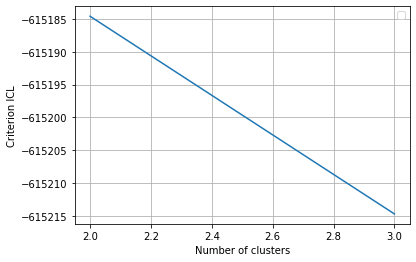

In [19]:
plt.plot(list_K,list_icl)
plt.grid()
plt.xlabel("Number of clusters")
plt.ylabel("Criterion ICL")
plt.legend()

In [21]:
tau = np.exp(log_tau)
partition = np.round(tau)
found = [np.argmax(partition[i,:]) for i in range(n)]
initial = [np.argmax(belong[i,:]) for i in range(n)]
ARI(initial,found)

0.7010228166797797

In [22]:
mat_lambda= np.exp(log_mat_lambda)

In [23]:
for i in range(5):
    for j in range(n):
        for t in range(int(G/2),len(list_mat_order)):
            partition_i = found[i]
            partition_j = found[j]
            monlambda1 = mat_lambda[partition_i,partition_j]
            list_mat_order[t][i,j] = np.random.poisson(monlambda1, 1)
            monlambda2 = mat_lambda[partition_j,partition_i]
            list_mat_order[t][j,i] = np.random.poisson(monlambda2, 1)
apprentissage = list_mat_order[:int(0.5*len(list_mat_order))]
t = len(list_mat_order)
validation = list_mat_order[int(0.5*t):int(0.75*t)]
test = list_mat_order[int(0.75*t):]


In [24]:
log_pi = log_vect_pi

In [25]:
# bootstrap non paramétrique
n =list_mat_order[0].shape[0]
niveau_theorique = 0.01
percentile=compute_percentile(niveau_theorique,apprentissage,log_pi,partition,log_mat_lambda,K,n)

[-1895.80124393 -1872.48735674 -1868.20947495 -1861.25387247
 -1860.95330413 -1860.53765118 -1860.34743715 -1858.47034613
 -1854.39555465 -1850.81010031 -1848.33020229 -1845.18993611
 -1842.03492052 -1841.35560019 -1841.10617393 -1836.09260978
 -1835.47527965 -1834.97257903 -1833.91335265 -1833.7126562
 -1829.95312159 -1829.05422015 -1828.96859276 -1828.10749154
 -1827.87445556 -1826.569844   -1825.68197342 -1825.27796445
 -1824.96718947 -1824.36804186 -1823.34781182 -1822.35093687
 -1821.706348   -1819.75170756 -1819.73549885 -1819.69175023
 -1819.29984479 -1819.27667921 -1818.94349724 -1818.83242316
 -1818.50114314 -1817.83227064 -1814.4670331  -1814.35883628
 -1811.89755031 -1807.33883172 -1806.63996456 -1806.25406413
 -1806.01576349 -1805.94252259 -1805.54388013 -1804.57876864
 -1802.71673673 -1801.9070728  -1801.56913882 -1801.06378891
 -1800.86686174 -1800.85973406 -1800.74147409 -1800.45572222
 -1800.26832912 -1799.03052013 -1798.70037206 -1798.28319553
 -1798.24247219 -1797.661

In [26]:
percentile

-1868.2094749545954

In [27]:
def log_vraisemblance(log_vect_pi,Z,mat_adj,log_lambda,K,n):
    lambda_ = np.exp(log_lambda)
    un_X = sp.csr_matrix(mat_adj)
    indices_ones = list(un_X.nonzero())
    numero_cluster = np.argwhere(Z)
    list_partition = np.array([numero_cluster[i,1] for i in range(n) ])
    list_k =list_partition[indices_ones[0]]
    list_l =list_partition[indices_ones[1]]

    if 0 in lambda_[list_k,list_l]:
        
        return(-np.inf)
    else:
        Z_sum = Z.sum(0)

        ll =  (Z_sum @ log_vect_pi).sum()
        #t = Z[indices_ones[0]].reshape(-1, K, 1)* Z[indices_ones[1]].reshape(-1, 1, K)*log_lambda.reshape(1, K, K)
        #t_prim=t.sum(1).sum(1)
        t = log_lambda[list_k,list_l]
        u = t@ un_X[indices_ones[0],indices_ones[1]].T
        #X_log_fact = [math.log(math.factorial(i)) for i in np.array(un_X[indices_ones[0],indices_ones[1]])[0]]
        X_log_fact=gammaln(np.array(un_X[indices_ones[0], indices_ones[1]])[0]+1)
        v = u - X_log_fact.sum()
        w = v - (((Z_sum.reshape((-1, 1)) * Z_sum) - Z.T @ Z)* lambda_).sum()
        ll =ll+ w

        return(ll)


In [28]:
# bootstrap non paramétrique
list_vraisemblance_true_graphs = []
acceptation = []
for mongraphe in validation:
    log_v = log_vraisemblance(log_pi,partition,mongraphe,log_mat_lambda,K_star,n)
    list_vraisemblance_true_graphs.append(log_v[0,0])
    acceptation.append(log_v[0,0]>percentile)

In [29]:
def compute_percentile(niveau_theorique,apprentissage,log_pi,partition,log_mat_lambda_1graphe,K,n):
    
    list_vraisemblance_train_graphs = []
    for mongraphe in apprentissage:
        log_v = log_vraisemblance(log_pi,partition,mongraphe,log_mat_lambda_1graphe,K,n)
        list_vraisemblance_train_graphs.append(log_v)
    list_vraisemblance = np.sort(list_vraisemblance_train_graphs)
    percentile = list_vraisemblance[int(niveau_theorique*len(apprentissage))]
    
    return(percentile)

In [30]:
dict((l,acceptation.count(l)) for l in set(acceptation))

{True: 125}

#### PUISSANCE ETOILE


In [31]:
nb_arêtes=[5,10,20,50,70,100,150,200,300]
nb_noeuds=10

In [32]:
#list_puissance,dico_graph_attaque,dico_bad_edge= puissance_edgenotnull(apprentissage,test,percentile,nb_branche, nb_arêtes,log_pi,partition,log_mat_lambda,K_star,n)

In [33]:
list_puissance,dico_graph_attaque,dico_bad_edge= puissance_star(nb_noeuds,nb_arêtes,test,percentile,log_pi,partition,log_mat_lambda,K_star,n)

[0, 0, 0, 0, 7.199999999999999, 92.80000000000001, 100.0, 100.0, 100.0]


In [34]:
list_puissance_0 = [0, 0, 0, 0, 0, 33.33333333333333, 100.0, 100.0, 100.0]


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


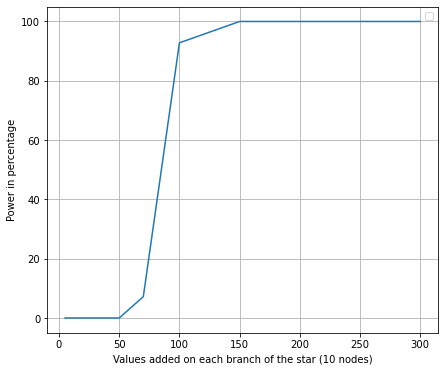

In [35]:

plt.figure(1,(7,6))

plt.plot(nb_arêtes,list_puissance)

plt.grid()
#plt.title("Power as a function of the number of edges added on a star with 5 nodes")
plt.xlabel("Values added on each branch of the star (10 nodes)")
plt.ylabel("Power in percentage")
plt.legend()

In [36]:
mat_lambda= np.exp(log_mat_lambda)

In [37]:
G  = len(apprentissage)
dico_pvalue=pvalues_edges(dico_graph_attaque, nb_arêtes, apprentissage,partition,log_pi,log_mat_lambda,mat_lambda,n,G)

In [38]:
mat_lambda

array([[97.9428125 , 22.78750968],
       [19.18637419, 28.468     ]])

0.5509671638215035


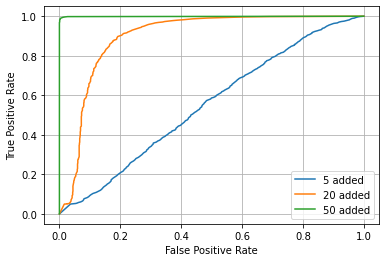

In [39]:
auc_20,thres_20,fpr_20,tpr_20=curve_roc_edge_allgraphs(dico_pvalue, dico_bad_edge,20,n)
auc_5,thres_5,fpr_5,tpr_5=curve_roc_edge_allgraphs(dico_pvalue, dico_bad_edge,5,n)
print(auc_5)
auc_50,thres_50,fpr_50,tpr_50=curve_roc_edge_allgraphs(dico_pvalue, dico_bad_edge,50,n)

plt.plot(fpr_5,tpr_5,label="5 added")
plt.plot(fpr_20,tpr_20,label="20 added")
plt.plot(fpr_50,tpr_50,label="50 added")

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.grid()
plt.legend()

### DEGRÉS 

In [40]:
dico_pval_node= ll_degree_test(apprentissage,log_tau,tau,mat_lambda,dico_graph_attaque,nb_arêtes,K,n)

In [41]:
mat_lambda

array([[97.9428125 , 22.78750968],
       [19.18637419, 28.468     ]])

In [42]:
niveau_theorique

0.01

In [43]:
dico_bad_edge[300][0]

[(12, 18),
 (12, 15),
 (12, 17),
 (12, 7),
 (12, 14),
 (12, 5),
 (12, 4),
 (12, 6),
 (12, 11)]

In [44]:
dico_pval_node[300][0][14]

0.752

In [45]:

list_puissance_node=pourcentage_réussite(niveau_theorique, dico_bad_edge,nb_arêtes,dico_pval_node)

In [46]:
list_puissance_node_0 = [2.666666666666667,
 2.666666666666667,
 42.66666666666667,
 100.0,
 100.0,
 100.0,
 100.0,
 100.0,
 100.0]


In [47]:
K_star

2

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


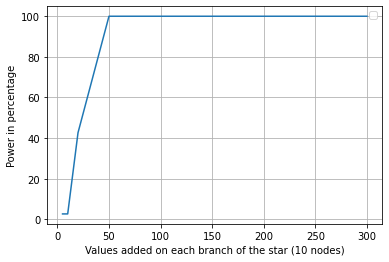

In [48]:


plt.plot(nb_arêtes,list_puissance_node_0)

plt.grid()
plt.xlabel("Values added on each branch of the star (10 nodes)")
plt.ylabel("Power in percentage")
plt.legend()

In [49]:
dico_bad_nodes={}
for nb_arête in nb_arêtes:
    bad_node_list = []
    for k in range(len(test)):
        pte_l=[]
        malist = dico_bad_edge[nb_arête][k]
        for i in malist:
            pte_l.append(i[0])
            pte_l.append(i[1])
        pte_l=list(set(pte_l))
        bad_node_list.append(pte_l)
    dico_bad_nodes[nb_arête]=bad_node_list
       

In [50]:
niveaux=[]
for nb_arête in nb_arêtes:
    acceptation=[]
    for c in range(len(test)):
        
        for k in range(n):
            if k not in dico_bad_nodes[nb_arête][c]:
                if dico_pval_node[nb_arête][c][k]<0.01:
                    acceptation.append(False)
                else:
                    acceptation.append(True)
    dico =dict((l, acceptation.count(l)) for l in set(acceptation))
    if True in dico.keys():
        niveau= (dico[True]/len(acceptation))*100
    else:
        niveau=0
    niveaux.append(niveau)

In [51]:
niveaux_0 = [98.86666666666667,
 99.0,
 98.73333333333333,
 98.53333333333333,
 98.93333333333332,
 98.8,
 99.0,
 99.13333333333333,
 99.0]

In [52]:
K_star

2

In [53]:
niveaux

[99.03999999999999,
 99.2,
 99.11999999999999,
 99.44,
 99.28,
 98.8,
 99.03999999999999,
 99.36,
 99.03999999999999]

In [54]:
niveaux_25 =[99.06666666666666,
 98.8,
 99.06666666666666,
 99.13333333333333,
 99.06666666666666,
 99.06666666666666,
 99.0,
 98.86666666666667,
 99.0]
niveaux_50 = [99.4,
 99.13333333333333,
 99.2,
 99.2,
 99.2,
 99.33333333333333,
 99.4,
 99.2,
 99.06666666666666]

In [55]:
K_star

2

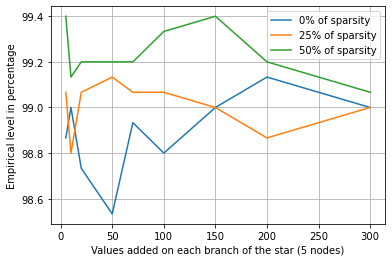

In [56]:

plt.plot(nb_arêtes,niveaux_0,label="0% of sparsity")
plt.plot(nb_arêtes,niveaux_25,label="25% of sparsity")
plt.plot(nb_arêtes,niveaux_50,label="50% of sparsity")

plt.grid()
plt.xlabel("Values added on each branch of the star (5 nodes)")
plt.ylabel("Empirical level in percentage")
plt.legend()